<img src="../Pierian-Data-Logo.PNG">
<br>
<strong><center>Copyright 2019. Created by Jose Marcial Portilla.</center></strong>

# RNN on a Time Series
For these examples we're using data from the Federal Reserve Economic Database (FRED) concerning Sales of Beer, Wine, and Distilled Alcoholic Beverages in millions of dollars from January 1992 to January 2019 (325 records).

Data source: https://fred.stlouisfed.org/series/S4248SM144NCEN

## Perform standard imports

In [2]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

# This relates to plotting datetime values with matplotlib:
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

## Load the dataset
We'll take advantage of pandas' built-in <a href='https://pandas.pydata.org/pandas-docs/stable/timeseries.html'>DatetimeIndex</a> by passing <tt>parse_dates=True</tt>

```python
import pandas_datareader.data as web
import datetime as dt

# Define the series ID
series_id = 'S4248SM144NCEN'

# Set the date range for the data you want
start_date = dt.datetime(1992, 1, 1)
end_date = dt.datetime.today().date().strftime("%Y-%m-%d")

# Download the data
df = web.DataReader(series_id, 'fred', start_date, end_date)

# Display the DataFrame
print(df.head())

```

In [3]:
import pandas_datareader.data as web
import datetime as dt

In [4]:
# Define the series ID
series_id = 'S4248SM144NCEN'

In [5]:
# Set the date range for the data you want
start_date = dt.datetime(1992, 1, 1)
end_date = dt.datetime.today().date().strftime("%Y-%m-%d")

In [7]:
# Download the data
df = web.DataReader(series_id, 'fred', start_date, end_date)

In [8]:
# Display the DataFrame
print(df.head())

            S4248SM144NCEN
DATE                      
1992-01-01            3459
1992-02-01            3458
1992-03-01            4002
1992-04-01            4564
1992-05-01            4221


In [9]:
df = df.copy()

In [10]:
df

,S4248SM144NCEN
DATE,
1992-01-01,3459
1992-02-01,3458
1992-03-01,4002
1992-04-01,4564
1992-05-01,4221
...,...
2025-12-01,18312
2026-01-01,12259
2026-02-01,12868


In [11]:
df["S4248SM144NCEN"].isnull().sum()

np.int64(0)

In [12]:
# Always a good idea with time series data:
df.dropna(inplace=True)
len(df)

412

In [13]:
df.head()

,S4248SM144NCEN
DATE,
1992-01-01,3459
1992-02-01,3458
1992-03-01,4002
1992-04-01,4564
1992-05-01,4221


In [14]:
df.tail()

,S4248SM144NCEN
DATE,
2025-12-01,18312
2026-01-01,12259
2026-02-01,12868
2026-03-01,15010
2026-04-01,15815


## Plotting time series data
We can add titles, axis labels, and other features to the plot.<br>
We're going to tighten the x-axis to fit the width of the actual data with <tt>plt.autoscale(axis='x',tight=True)</tt>.<br>
Alternatively you could set your own limits with <tt>plt.xlim(pd.Timestamp('1992-01-01'), pd.Timestamp('2019-01-01'))</tt> or some other values.

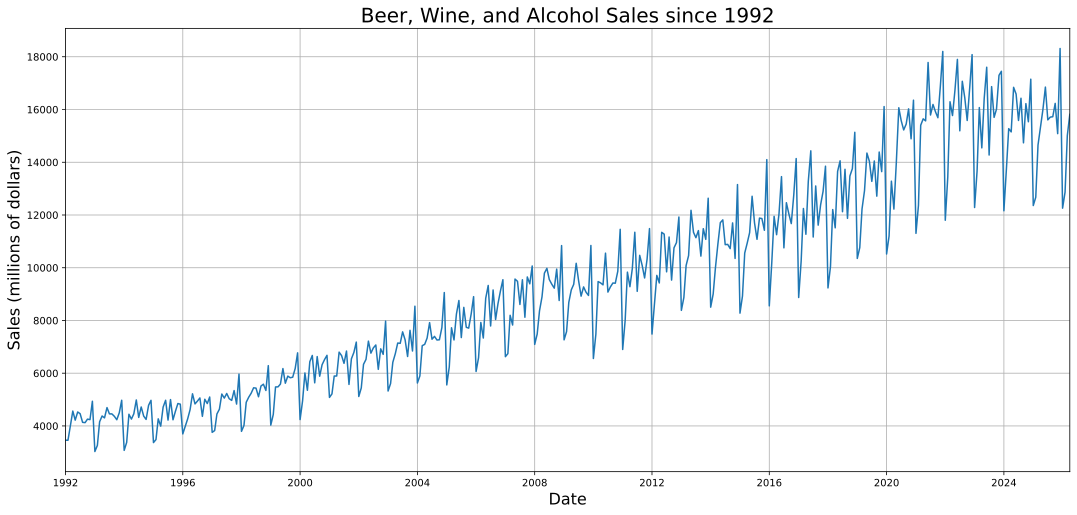

In [16]:
plt.figure(figsize=(18,8))
plt.title('Beer, Wine, and Alcohol Sales since 1992' , fontsize = 20)
plt.ylabel('Sales (millions of dollars)' , fontsize = 16)
plt.xlabel('Date' , fontsize = 16)
plt.grid(True)
plt.autoscale(axis='x',tight=True)
plt.plot(df['S4248SM144NCEN'])
plt.show()

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 412 entries, 1992-01-01 to 2026-04-01
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   S4248SM144NCEN  412 non-null    int64
dtypes: int64(1)
memory usage: 6.4 KB


## Prepare the data
In the next steps we'll divide the data into train/test sets, then normalize the training values so that they fall between -1 and 1 (to improve training). We'll train the model, then predict into a period that matches the test set. Finally, we'll forecast into an unknown future.

In [18]:
# Extract values from the source .csv file
y = df['S4248SM144NCEN'].values.astype(float)
y

array([ 3459.,  3458.,  4002.,  4564.,  4221.,  4529.,  4466.,  4137.,
        4126.,  4259.,  4240.,  4936.,  3031.,  3261.,  4160.,  4377.,
        4307.,  4696.,  4458.,  4457.,  4364.,  4236.,  4500.,  4974.,
        3075.,  3377.,  4443.,  4261.,  4460.,  4985.,  4324.,  4719.,
        4374.,  4248.,  4784.,  4971.,  3370.,  3484.,  4269.,  3994.,
        4715.,  4974.,  4223.,  5000.,  4235.,  4554.,  4851.,  4826.,
        3699.,  3983.,  4262.,  4619.,  5219.,  4836.,  4941.,  5062.,
        4365.,  5012.,  4850.,  5097.,  3758.,  3825.,  4454.,  4635.,
        5210.,  5057.,  5231.,  5034.,  4970.,  5342.,  4831.,  5965.,
        3796.,  4019.,  4898.,  5090.,  5237.,  5447.,  5435.,  5107.,
        5515.,  5583.,  5346.,  6286.,  4032.,  4435.,  5479.,  5483.,
        5587.,  6176.,  5621.,  5889.,  5828.,  5849.,  6180.,  6771.,
        4243.,  4952.,  6008.,  5353.,  6435.,  6673.,  5636.,  6630.,
        5887.,  6322.,  6520.,  6678.,  5082.,  5216.,  5893.,  5894.,
      

In [19]:
# Define a test size: since it is a monthly series, 12 months is a good test size
test_size = 12

In [20]:
# Create train and test sets
train_set = y[:-test_size]
test_set = y[-test_size:]

In [21]:
len(train_set)

400

In [22]:
len(test_set)

12

In [23]:
test_set

array([15997., 16849., 15607., 15711., 15726., 16231., 15085., 18312.,
       12259., 12868., 15010., 15815.])

It's worth noting that in our previous exercise the train and test sets were tensors. Here they're numpy arrays. This is because one of the steps we're about to perform outputs an array, and we'd have to turn it into a tensor anyway.

## Normalize the data
The formula for normalizing data around zero is:<br>
### $X_{norm} = \frac{X - \mu} {\sigma}$
where $\mu$ is the population mean, and $\sigma$ is the population standard deviation.<br>
Recall that back in the CNN section we transformed image files using <a href='https://pytorch.org/docs/stable/torchvision/transforms.html#torchvision.transforms.Normalize'><tt><strong>torchvision.transforms.Normalize(<em>mean, std</em>)</strong></tt></a>, both because it was built into DataLoader, and because our pretrained models expected specific normalization values.<br>

Ultimately we want to perform <a href='https://en.wikipedia.org/wiki/Feature_scaling'>min/max feature scaling</a> so that our values fall between -1 and 1, as this makes hyperparameters converge faster.<br>The formula for this would be:<br>
### $X^{\prime} = a + \frac{(X - X_{min}) (b - a)} {X_{max} - X_{min}}$
where $a={-1}$ and $b=1$<br>

We can use scikit-learn to do this, with <a href='https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html'><tt><strong>sklearn.preprocessing.MinMaxScaler()</strong></tt></a>

NOTE: We only want to normalize the training set to avoid data leakage. If we include the test set then the higher average values of the test set could become part of the signal in the training set. There's a good article on data leakage <a href='test_set = input_data(test_norm,window_size)'>here</a>.

After using transformed data to train the model and generate predictions, we'll inverse_transform the predicted values so that we can compare them to the actual test data.

In [24]:
from sklearn.preprocessing import MinMaxScaler

In [25]:
# Instantiate a scaler with a feature range from -1 to 1
scaler = MinMaxScaler(feature_range=(-1, 1))

In [35]:
scaler

MinMaxScaler(feature_range=(-1, 1))

In [27]:
train_set.reshape(-1, 1)[:5]

array([[3459.],
       [3458.],
       [4002.],
       [4564.],
       [4221.]])

We can first of all fit and then transform:
```python
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(train_set.reshape(-1,1))
train_norm = scaler.transform(train_set.reshape(-1,+1))
```

or we can do it in one-shot:
```python
scaler = MinMaxScaler(feature_range=(-1, 1))
train_norm = scaler.fit_transform(train_set.reshape(-1,+1))

```

In [28]:
# Normalize the training set
train_norm = scaler.fit_transform(train_set.reshape(-1, 1))

In [29]:
train_norm.min()

np.float64(-1.0)

In [30]:
train_norm.max()

np.float64(1.0)

In [31]:
train_norm.mean()

np.float64(-0.18866348055372456)

In [32]:
type(train_norm)

numpy.ndarray

In [33]:
import scipy.stats as stats

In [34]:
stats.describe(train_norm)

DescribeResult(nobs=np.int64(400), minmax=(array([-1.]), array([1.])), mean=array([-0.18866348]), variance=array([0.26194495]), skewness=array([0.43837184]), kurtosis=array([-0.83036482]))

## Prepare data for LSTM
Here we'll create our list of (seq/label) tuples from the training set. Recall that an LSTM consumes a window of samples toward the first prediction, so the size of our training set will become ((325 - test_size) - window_size).

In [36]:
# Convert train_norm from an array to a tensor
train_norm = torch.FloatTensor(train_norm).view(-1)
train_norm[:5]

tensor([-0.9436, -0.9437, -0.8720, -0.7979, -0.8431])

In [37]:
len(train_norm)

400

In [38]:
# Define a window size
window_size = 12

In [39]:
# Define function to create seq/label tuples
def input_data(seq,ws):  # ws is the window size
    out = []
    L = len(seq)
    for i in range(L-ws):
        window = seq[i:i+ws]
        label = seq[i+ws:i+ws+1]
        out.append((window,label))
    return out

In [40]:
# Apply the input_data function to train_norm
train_data = input_data(train_norm,window_size)
len(train_data)  # this should equal len(train_norm) - window_size

388

In [41]:
# Display the first seq/label tuple in the train data
train_data[0]

(tensor([-0.9436, -0.9437, -0.8720, -0.7979, -0.8431, -0.8025, -0.8108, -0.8542,
         -0.8556, -0.8381, -0.8406, -0.7488]),
 tensor([-1.]))

## Define the model
This time we'll use an LSTM layer of size (1,100).

In [43]:
class LSTMnetwork(nn.Module):
    def __init__(self,input_size=1,hidden_size=100,output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        
        # Add an LSTM layer:
        self.lstm = nn.LSTM(input_size,hidden_size)
        
        # Add a fully-connected layer:
        self.linear = nn.Linear(hidden_size,output_size)
        
        # Initialize h0 and c0:
        self.hidden = (torch.zeros(1,1,self.hidden_size),
                       torch.zeros(1,1,self.hidden_size))

    def forward(self,seq):
        lstm_out , self.hidden = self.lstm(seq.view(len(seq),1,-1), self.hidden)
        pred = self.linear(lstm_out.view(len(seq),-1))
        return pred[-1]  # we only want the last value

## Instantiate the model, define loss and optimization functions

In [44]:
torch.manual_seed(101)
model = LSTMnetwork()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model

LSTMnetwork(
  (lstm): LSTM(1, 100)
  (linear): Linear(in_features=100, out_features=1, bias=True)
)

In [45]:
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6,}')
    print(f'______\n{sum(params):>6,}')
    
count_parameters(model)

   400
40,000
   400
   400
   100
     1
______
41,301


In [46]:
for p in model.named_parameters():
    if "weight" in p[0]:
        print(f"{p[0]} has size of {list(p[1].shape)}.")

lstm.weight_ih_l0 has size of [400, 1].
lstm.weight_hh_l0 has size of [400, 100].
linear.weight has size of [1, 100].


## Train the model

In [47]:
epochs = 100

import time
start_time = time.time()

for epoch in range(epochs):
    
    # extract the sequence & label from the training data
    for seq, y_train in train_data:
        
        # reset the parameters and hidden states
        optimizer.zero_grad()
        model.hidden = (torch.zeros(1,1,model.hidden_size),
                        torch.zeros(1,1,model.hidden_size))
        
        y_pred = model(seq)
        
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        
    # print training result
    print(f'Epoch: {epoch+1:2} Loss: {loss.item():10.8f}')
    
print(f'\nDuration: {time.time() - start_time:.0f} seconds')

Epoch:  1 Loss: 0.00299155
Epoch:  2 Loss: 0.00059943
Epoch:  3 Loss: 0.00316148
Epoch:  4 Loss: 0.00107583
Epoch:  5 Loss: 0.00028719
Epoch:  6 Loss: 0.00004400
Epoch:  7 Loss: 0.00000064
Epoch:  8 Loss: 0.00000707
Epoch:  9 Loss: 0.00002847
Epoch: 10 Loss: 0.00004008
Epoch: 11 Loss: 0.00012907
Epoch: 12 Loss: 0.00000193
Epoch: 13 Loss: 0.00000031
Epoch: 14 Loss: 0.00004708
Epoch: 15 Loss: 0.00002296
Epoch: 16 Loss: 0.00095112
Epoch: 17 Loss: 0.00393217
Epoch: 18 Loss: 0.01012431
Epoch: 19 Loss: 0.01548207
Epoch: 20 Loss: 0.00302971
Epoch: 21 Loss: 0.00045975
Epoch: 22 Loss: 0.00025970
Epoch: 23 Loss: 0.00028983
Epoch: 24 Loss: 0.00044645
Epoch: 25 Loss: 0.00084355
Epoch: 26 Loss: 0.00004945
Epoch: 27 Loss: 0.00001966
Epoch: 28 Loss: 0.00000028
Epoch: 29 Loss: 0.00067929
Epoch: 30 Loss: 0.00158160
Epoch: 31 Loss: 0.00253192
Epoch: 32 Loss: 0.00351630
Epoch: 33 Loss: 0.00000457
Epoch: 34 Loss: 0.00548119
Epoch: 35 Loss: 0.00812436
Epoch: 36 Loss: 0.00890209
Epoch: 37 Loss: 0.00135144
E

## Run predictions and compare to known test set

In [48]:
future = 12

# Add the last window of training values to the list of predictions
preds = train_norm[-window_size:].tolist()

# Set the model to evaluation mode
model.eval()

for i in range(future):
    seq = torch.FloatTensor(preds[-window_size:])
    with torch.no_grad():
        model.hidden = (torch.zeros(1,1,model.hidden_size),
                        torch.zeros(1,1,model.hidden_size))
        preds.append(model(seq).item())

In [49]:
# Display predicted values
preds[window_size:]    # equivalent to preds[-future:]

[0.7942328453063965,
 0.9086117148399353,
 0.7528021335601807,
 0.8169299364089966,
 0.6771936416625977,
 0.7145720720291138,
 0.7603634595870972,
 0.946688711643219,
 0.16132965683937073,
 0.4432966113090515,
 0.6968835592269897,
 0.5482385158538818]

## Invert the normalization
We want to compare our test predictions to the original data, so we need to undo the previous normalization step. Note that <tt>inverse_transform</tt> uses the most recently applied parameters; we can rescale based on the test data, but not on the previous training data.

In [52]:
true_predictions = scaler.inverse_transform(np.array(preds[window_size:]).reshape(-1, 1))
true_predictions

array([[16640.25613165],
       [17507.81985706],
       [16326.00418305],
       [16812.41356766],
       [15752.51377201],
       [16036.02916634],
       [16383.35684097],
       [17796.63387781],
       [11839.68544713],
       [13978.40479678],
       [15901.86179674],
       [14774.38914275]])

In [53]:
df['S4248SM144NCEN'][-12:]

,S4248SM144NCEN
DATE,
2025-05-01,15997
2025-06-01,16849
2025-07-01,15607
2025-08-01,15711
2025-09-01,15726
2025-10-01,16231
2025-11-01,15085
2025-12-01,18312
2026-01-01,12259


In [55]:
df['S4248SM144NCEN'][-12:].index[0].strftime('%Y-%m-%d')

'2025-05-01'

It looks like our predictions weren't that far off!
## Plot the results
Our original data contains a datetime index, but our predicted values do not. We can create a range of dates using NumPy that are spaced one month apart using <tt>dtype='datetime64[M]'</tt>, and then store them with day values to match our dataset with <tt>.astype('datetime64[D]')</tt>.

In [56]:
start_time_date = df['S4248SM144NCEN'][-12:].index[0].strftime('%Y-%m-%d')
end_time_date = df['S4248SM144NCEN'][-12:].index[-1].strftime('%Y-%m-%d')

print(start_time_date)
print(end_time_date)

2025-05-01
2026-04-01


In [57]:
# Remember that the stop date has to be later than the last predicted value.
x = pd.date_range(start = start_time_date, end = end_time_date, freq = 'MS')
x

DatetimeIndex(['2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01',
               '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01',
               '2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01'],
              dtype='datetime64[ns]', freq='MS')

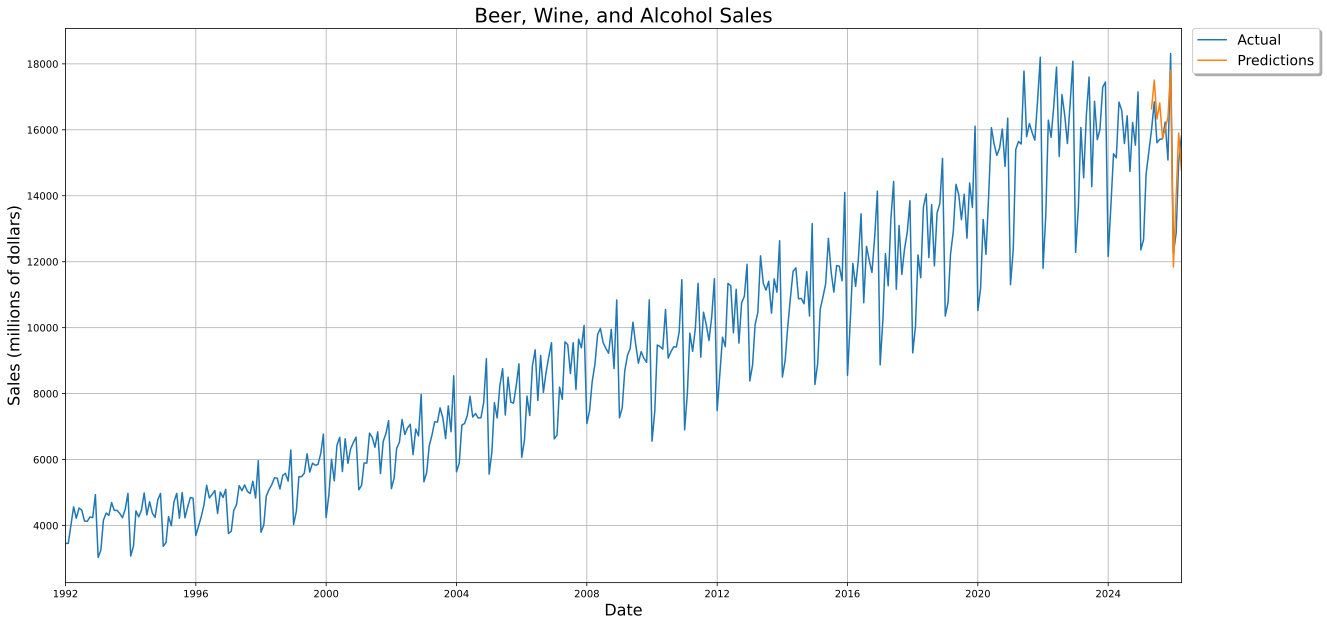

In [62]:
plt.figure(figsize=(20,10))
plt.title('Beer, Wine, and Alcohol Sales' , fontsize = 20)
plt.ylabel('Sales (millions of dollars)', fontsize = 16)
plt.xlabel('Date', fontsize = 16)
plt.grid(True)
plt.autoscale(axis='x',tight=True)
plt.plot(df['S4248SM144NCEN'] , label = 'Actual')
plt.plot(x,true_predictions , label = 'Predictions')
plt.legend(fontsize=14, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0. , frameon=True , fancybox=True, shadow=True, ncol=1)
plt.show()

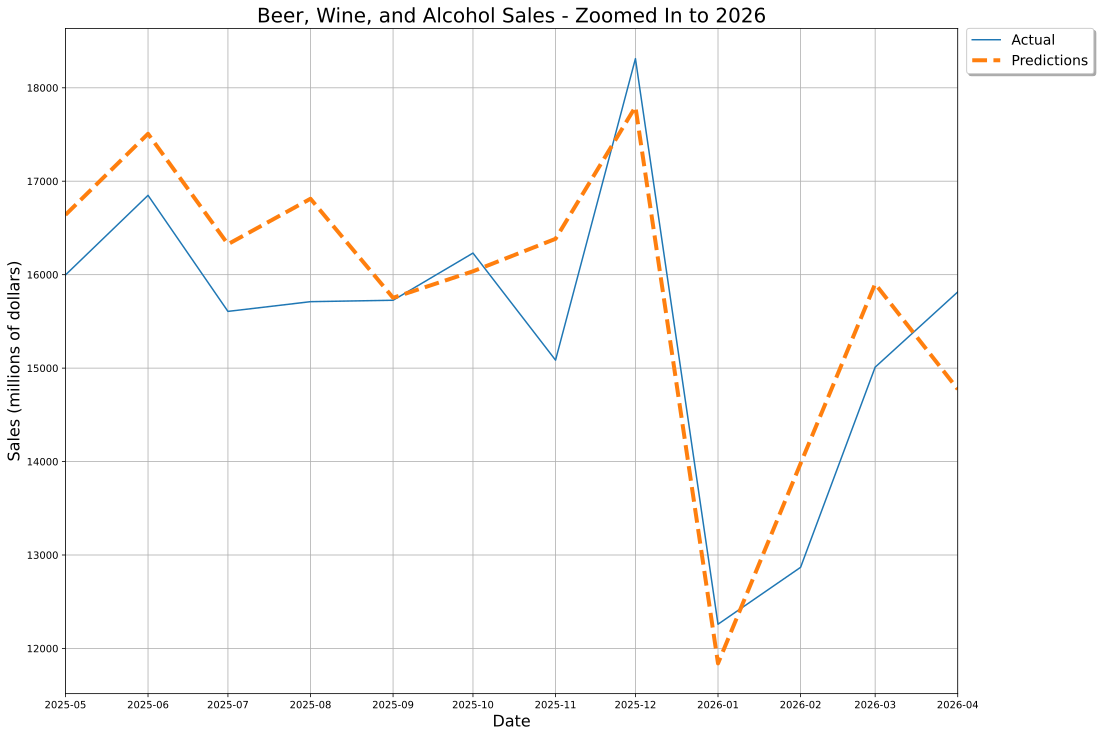

In [69]:
plt.figure(figsize=(16,12))
plt.title('Beer, Wine, and Alcohol Sales - Zoomed In to 2026' , fontsize = 20)
plt.ylabel('Sales (millions of dollars)' , fontsize = 16)
plt.xlabel('Date', fontsize = 16)
plt.grid(True)
plt.autoscale(axis='x',tight=True)
plt.plot(df.loc['2025-05':, 'S4248SM144NCEN'] , label = 'Actual')
plt.plot(x,true_predictions , label = 'Predictions' , ls = '--' , lw = 4)
plt.legend(fontsize=14, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0. , frameon=True , fancybox=True, shadow=True, ncol=1)
plt.show()

For more information on x-axis date formatting in matplotlib, check out <a href='https://matplotlib.org/api/_as_gen/matplotlib.figure.Figure.html#matplotlib.figure.Figure.autofmt_xdate'><tt><strong>matplotlib.figure.Figure.autofmt_xdate</strong></tt></a> and <a href='https://matplotlib.org/api/dates_api.html#matplotlib.dates.DateFormatter'><tt><strong>matplotlib.dates.DateFormatter</strong></tt></a>

# Forecast into an unknown future
This time we'll continue training the model using the entire dataset, and predict 12 steps into the future.

In [70]:
epochs = 100

# set model to back to training mode
model.train()

# feature scale the entire dataset
y_norm = scaler.fit_transform(y.reshape(-1, 1))
y_norm = torch.FloatTensor(y_norm).view(-1)
all_data = input_data(y_norm,window_size)

import time
start_time = time.time()

for epoch in range(epochs):
    
    # train on the full set of sequences
    for seq, y_train in all_data:  
        
        # reset the parameters and hidden states
        optimizer.zero_grad()
        model.hidden = (torch.zeros(1,1,model.hidden_size),
                        torch.zeros(1,1,model.hidden_size))
        
        y_pred = model(seq)
        
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        
    # print training result
    print(f'Epoch: {epoch+1:2} Loss: {loss.item():10.8f}')
    
print(f'\nDuration: {time.time() - start_time:.0f} seconds')

Epoch:  1 Loss: 0.00059537
Epoch:  2 Loss: 0.00246802
Epoch:  3 Loss: 0.00465845
Epoch:  4 Loss: 0.00363562
Epoch:  5 Loss: 0.00090860
Epoch:  6 Loss: 0.00062088
Epoch:  7 Loss: 0.00005055
Epoch:  8 Loss: 0.00052511
Epoch:  9 Loss: 0.00162629
Epoch: 10 Loss: 0.00088976
Epoch: 11 Loss: 0.00029465
Epoch: 12 Loss: 0.00015734
Epoch: 13 Loss: 0.00020857
Epoch: 14 Loss: 0.00452868
Epoch: 15 Loss: 0.00075622
Epoch: 16 Loss: 0.00026315
Epoch: 17 Loss: 0.00033411
Epoch: 18 Loss: 0.00078102
Epoch: 19 Loss: 0.00034228
Epoch: 20 Loss: 0.00004951
Epoch: 21 Loss: 0.00024654
Epoch: 22 Loss: 0.00028971
Epoch: 23 Loss: 0.00013475
Epoch: 24 Loss: 0.00011721
Epoch: 25 Loss: 0.00072728
Epoch: 26 Loss: 0.00039311
Epoch: 27 Loss: 0.00252017
Epoch: 28 Loss: 0.00000063
Epoch: 29 Loss: 0.00108410
Epoch: 30 Loss: 0.00054983
Epoch: 31 Loss: 0.00119751
Epoch: 32 Loss: 0.00048920
Epoch: 33 Loss: 0.00042452
Epoch: 34 Loss: 0.00000483
Epoch: 35 Loss: 0.00011515
Epoch: 36 Loss: 0.00005296
Epoch: 37 Loss: 0.00080621
E

## Predict future values, plot the result

In [71]:
window_size = 12
future = 12
L = len(y)

preds = y_norm[-window_size:].tolist()

model.eval()
for i in range(future):  
    seq = torch.FloatTensor(preds[-window_size:])
    with torch.no_grad():
        # Reset the hidden parameters here!
        model.hidden = (torch.zeros(1,1,model.hidden_size),
                        torch.zeros(1,1,model.hidden_size))  
        preds.append(model(seq).item())

# Inverse-normalize the prediction set
true_predictions = scaler.inverse_transform(np.array(preds).reshape(-1, 1))

In [74]:
df['S4248SM144NCEN']

,S4248SM144NCEN
DATE,
1992-01-01,3459
1992-02-01,3458
1992-03-01,4002
1992-04-01,4564
1992-05-01,4221
...,...
2025-12-01,18312
2026-01-01,12259
2026-02-01,12868


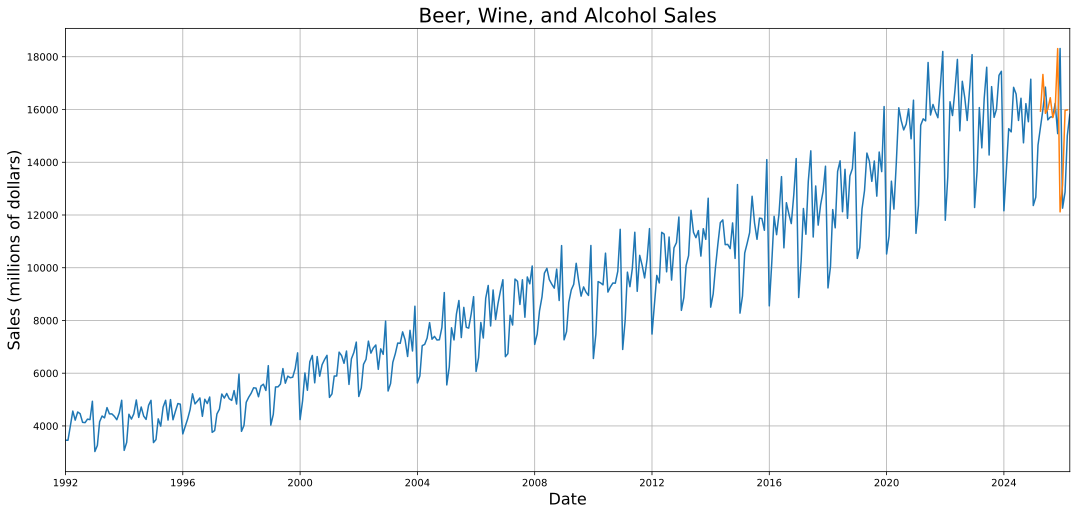

In [76]:

# PLOT THE RESULT
# Set a data range for the predicted data.
# Remember that the stop date has to be later than the last predicted value.
x = np.arange('2025-04-01', '2026-04-01', dtype='datetime64[M]').astype('datetime64[D]')

plt.figure(figsize=(18,8))
plt.title('Beer, Wine, and Alcohol Sales' , fontsize = 20)
plt.ylabel('Sales (millions of dollars)' , fontsize = 16)
plt.xlabel('Date', fontsize = 16)
plt.grid(True)
plt.autoscale(axis='x',tight=True)
plt.plot(df['S4248SM144NCEN'])
plt.plot(x,true_predictions[window_size:])
plt.show()

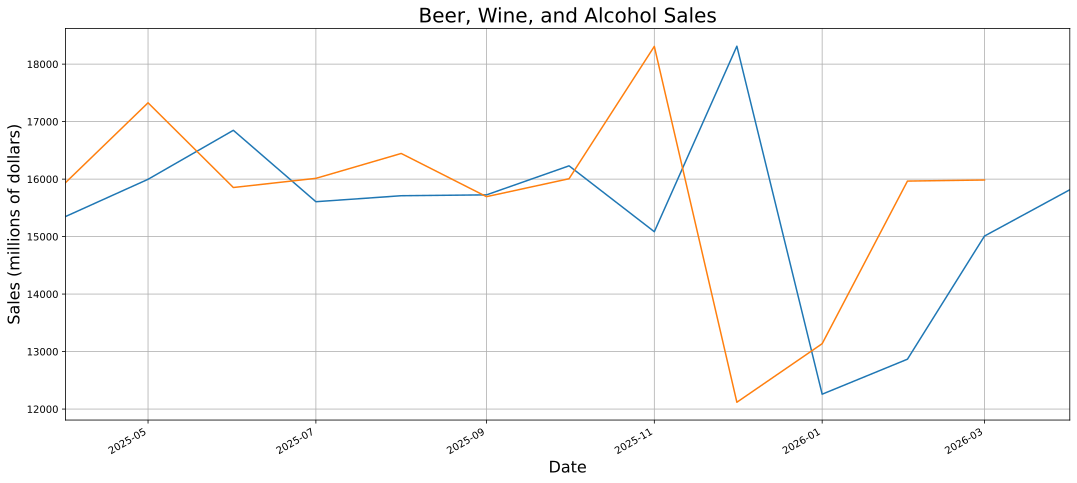

In [78]:
fig = plt.figure(figsize=(18,8))
plt.title('Beer, Wine, and Alcohol Sales' , fontsize = 20)
plt.ylabel('Sales (millions of dollars)' , fontsize = 16)
plt.xlabel('Date', fontsize = 16)
plt.grid(True)
plt.autoscale(axis='x',tight=True)
fig.autofmt_xdate()
plt.plot(df['S4248SM144NCEN']['2025-04-01':])
plt.plot(x,true_predictions[window_size:])
plt.show()

## Great job!

<h3>BONUS:</h3>To save time in the future, we've written a function that will take in a time series training data set, and output a tensor of <tt>(seq, label)</tt> tuples.

In [31]:
# Load dependencies
from sklearn.preprocessing import MinMaxScaler

# Instantiate a scaler
"""
This has to be done outside the function definition so that
we can inverse_transform the prediction set later on.
"""
scaler = MinMaxScaler(feature_range=(-1, 1))

# Extract values from the source .csv file
df = pd.read_csv('../Data/TimeSeriesData/Alcohol_Sales.csv',index_col=0,parse_dates=True)
y = df['S4248SM144NCEN'].values.astype(float)

# Define a test size
test_size = 12

# Create the training set of values
train_set = y[:-test_size]

In [32]:
# DEFINE A FUNCTION:
def create_train_data(seq,ws=12):
    """Takes in a training sequence and window size (ws) of
       default size 12, returns a tensor of (seq/label) tuples"""
    seq_norm = scaler.fit_transform(seq.reshape(-1, 1))    
    seq_norm = torch.FloatTensor(seq_norm).view(-1)

    out = []
    L = len(seq_norm)
    for i in range(L-ws):
        window = seq_norm[i:i+ws]
        label = seq_norm[i+ws:i+ws+1]
        out.append((window,label))
    return out

In [33]:
# Apply the function to train_set
train_data = create_train_data(train_set,12)
len(train_data)  # this should equal 313-12

301

In [34]:
train_data[0]

(tensor([-0.9268, -0.9270, -0.8340, -0.7379, -0.7966, -0.7439, -0.7547, -0.8109,
         -0.8128, -0.7901, -0.7933, -0.6743]), tensor([-1.]))

In [35]:
help(create_train_data)

Help on function create_train_data in module __main__:

create_train_data(seq, ws=12)
    Takes in a training sequence and window size (ws) of
    default size 12, returns a tensor of (seq/label) tuples

